In [20]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
source(here::here("load_archr.R"))
library(viridis)

# I/O
#io$outdir =  file.path(io$output.directory,"cluster_annotation")
#dir.create(io$outdir, showWarnings = FALSE)

addArchRThreads(1)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [21]:
ArchRProject


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Project 
samples(8): rabbit_BGRGP1 rabbit_BGRGP2 ... rabbit_BGRGP7 rabbit_BGRGP8
sampleColData names(1): ArrowFiles
cellColData names(42): stage_clusters.3 sample ... cell.4
  celltype_manual_refined
numberOfCells(1): 50525
medianTSS(1): 3.353
medianFrags(1): 34982

# Subset

Rather than only isolating cells labelled trophoblast, SCT, or CYT, I isolate all cells that are grouped in that area of the UMAP

In [45]:
keep_celltypes = c('Trophoblast', 'CYT', 'SCT')

In [46]:
umap = getEmbedding(ArchRProject, embedding = 'UMAP_PeakMatrix')
colnames(umap) = c('umap1', 'umap2')

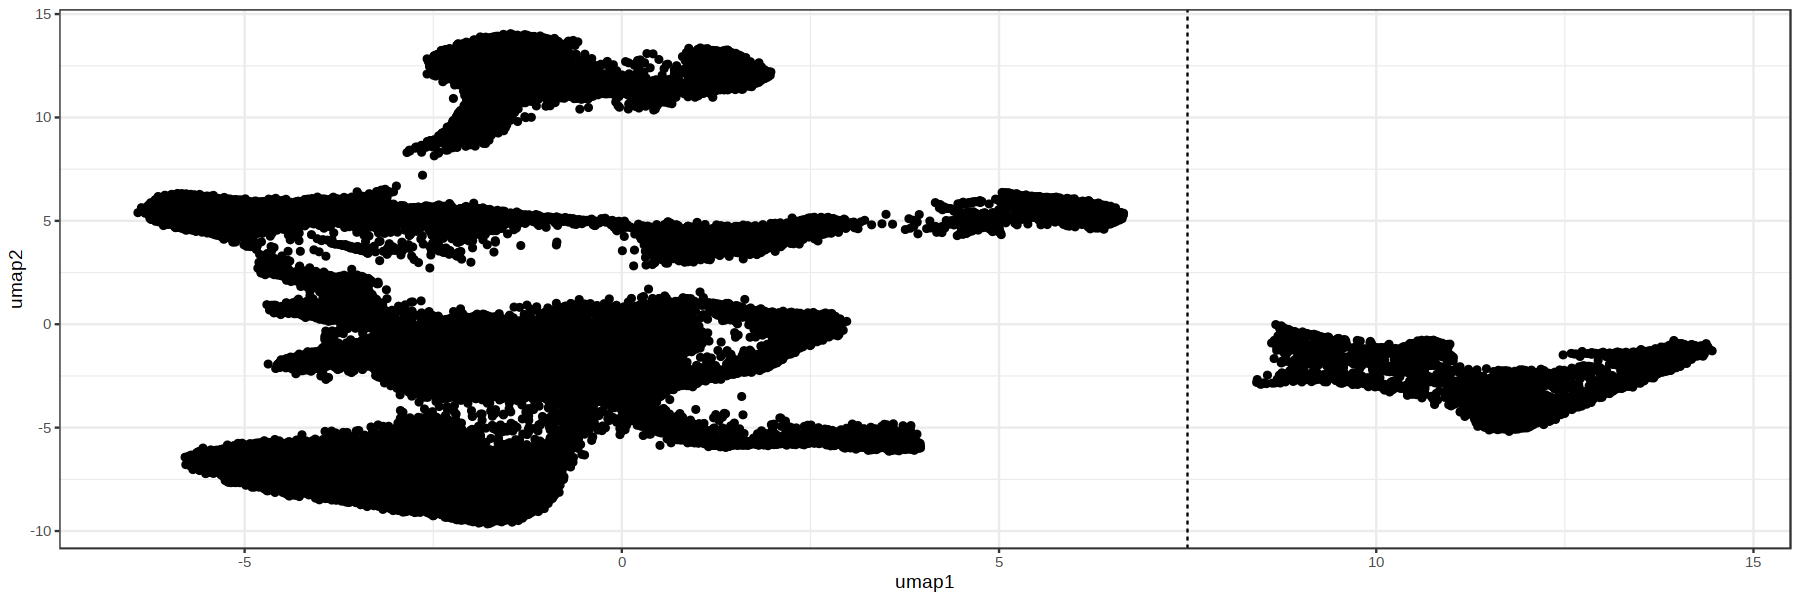

In [47]:
ggplot(umap, aes(umap1, umap2)) + 
    geom_point() +
    geom_vline(xintercept=7.5, linetype='dashed') + 
    theme_bw()

In [48]:
# Select cells of umap group
keep_umap = rownames(umap[umap$umap1>7.5,])

In [49]:
keep_cells = ArchRProject@cellColData[ArchRProject@cellColData$celltype_manual_refined %in% keep,]$cell
keep_cells = intersect(keep_cells, keep_umap)

In [54]:
subsetArchRProject(
  ArchRProj = ArchRProject,
  cells = keep_cells,
  outputDirectory = "Trophoblast",
  dropCells = TRUE,
  logFile = NULL,
  threads = getArchRThreads(),
  force = TRUE
)

Dropping ImputeWeights Since You Are Subsetting Cells! ImputeWeights is a cell-x-cell Matrix!

Copying ArchRProject to new outputDirectory : /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Trophoblast

Copying Arrow Files...

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

.copyArrow : Initializing Out ArrowFile

.copyArrow : Adding Metadata to Out ArrowFile

.copyArrow : Adding SubMatrices to Out ArrowFile

Getting ImputeWeights

No imputeWeights found, returning NULL

Copying Other Files...

Copying Other Files (1 of 10): Annotations

Copying Other Files (2 of 10): Background-Peaks.rds

Copying Other Files (3 of 10): GroupCoverages

Copying Other Files (4 of 10): IterativeLSI

Copying Other Files (5 of 10): Peak2GeneLinks

Copying Other Fil

class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Trophoblast 
samples(3): rabbit_BGRGP1 rabbit_BGRGP3 rabbit_BGRGP2
sampleColData names(1): ArrowFiles
cellColData names(42): stage_clusters.3 sample ... cell.4
  celltype_manual_refined
numberOfCells(1): 4495
medianTSS(1): 3.093
medianFrags(1): 39653

# Load Trophoblast trajectory

In [1]:
here::i_am("snakemake/01_create_arrow.R")
source(here::here("settings.R"))
ArchRProject <- loadArchRProject(file.path(io$basedir, 'ArchR/Trophoblast'))
library(viridis)

# I/O
io$plot.trophoblast = file.path(io$basedir, 'ArchR/Trophoblast/plots')
dir.create(io$plot.trophoblast, showWarnings = FALSE)

addArchRThreads(1)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final

Setting default number of Parallel threads to 1.

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-' 

In [2]:
trajectory <- c("Trophoblast", "CYT", "SCT")

In [3]:
ArchRProject <- addTrajectory(
    ArchRProj = ArchRProject, 
    name = "Tropho", 
    groupBy = "celltype_manual_refined",
    trajectory = trajectory, 
    embedding = "UMAP_PeakMatrix", 
    force = TRUE
)

ArchR logging to : ArchRLogs/ArchR-addTrajectory-1fdaf59f1fa2a-Date-2022-01-18_Time-16-05-25.log
If there is an issue, please report to github with logFile!

Filtering outliers

Initial Alignment Before Spline Fit

Spline Fit

KNN to Spline

ArchR logging successful to : ArchRLogs/ArchR-addTrajectory-1fdaf59f1fa2a-Date-2022-01-18_Time-16-05-25.log



ArchR logging to : ArchRLogs/ArchR-plotTrajectory-1fdaf4efbd2a9-Date-2022-01-18_Time-16-05-25.log
If there is an issue, please report to github with logFile!

Plotting

Warning message:
“Removed 450 rows containing non-finite values (stat_summary_hex).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-1fdaf4efbd2a9-Date-2022-01-18_Time-16-05-25.log

Warning message:
“Removed 450 rows containing non-finite values (stat_summary_hex).”


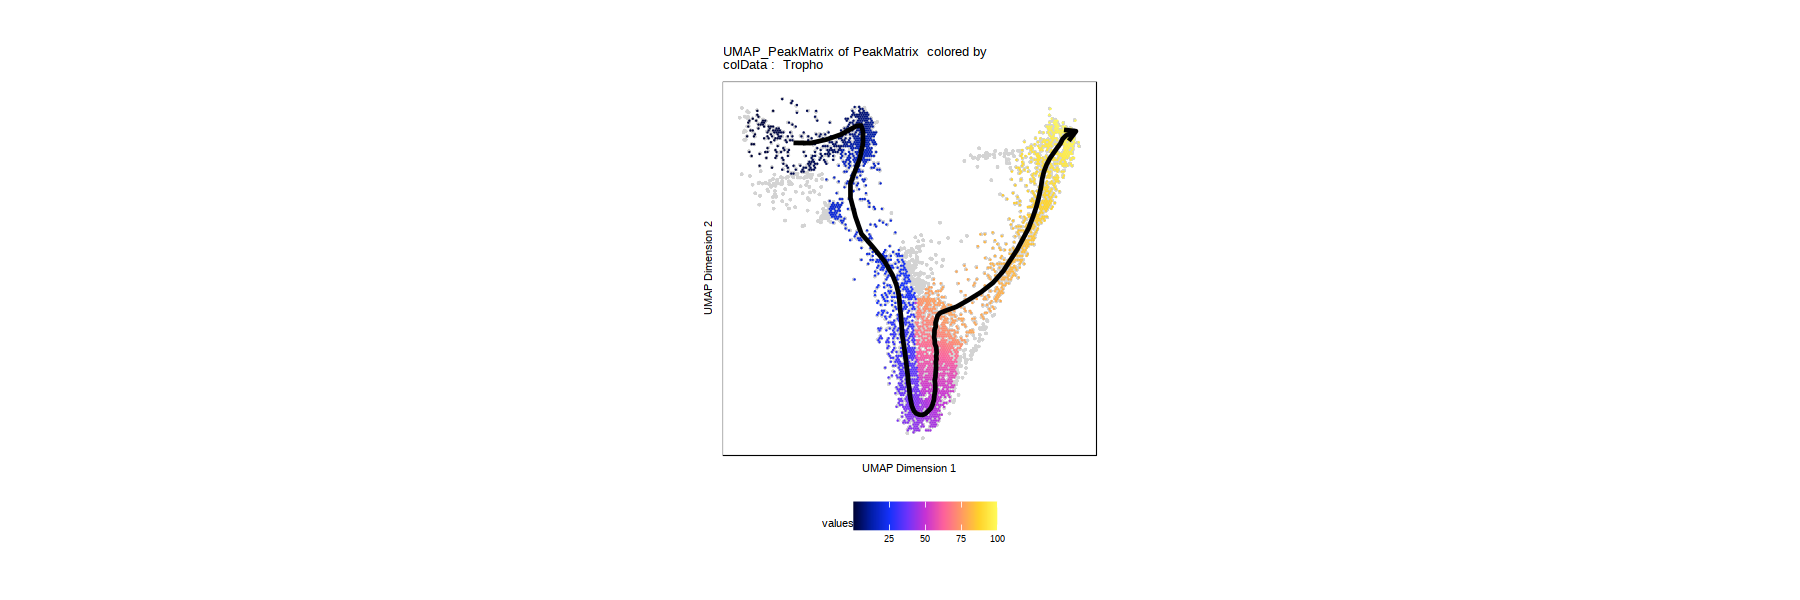

In [4]:
p <- plotTrajectory(ArchRProject, trajectory = "Tropho", colorBy = "cellColData", name = "Tropho", embedding = "UMAP_PeakMatrix")
p[[1]]

In [5]:
ArchRProject = addImputeWeights(ArchRProject,reducedDims='PeakMatrix')

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-1fdaf6577b390-Date-2022-01-18_Time-16-05-43.log
If there is an issue, please report to github with logFile!

2022-01-18 16:05:43 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”


Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotTrajectory-b5c478e59a52-Date-2022-01-17_Time-14-50-30.log
If there is an issue, please report to github with logFile!

Getting Matrix Values...

2022-01-17 14:50:31 : 

1 
2 
3 


Imputing Matrix

Using weights on disk

1 of 1

Plotting

Warning message:
“Removed 450 rows containing non-finite values (stat_summary_hex).”
Plotting Trajectory

Adding Inferred Arrow Trajectory to Plot

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectory-b5c478e59a52-Date-2022-01-17_Time-14-50-30.log

Warning message:
“Removed 450 rows containing non-finite values (stat_summary_hex).”
`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



[[1]]

[[2]]


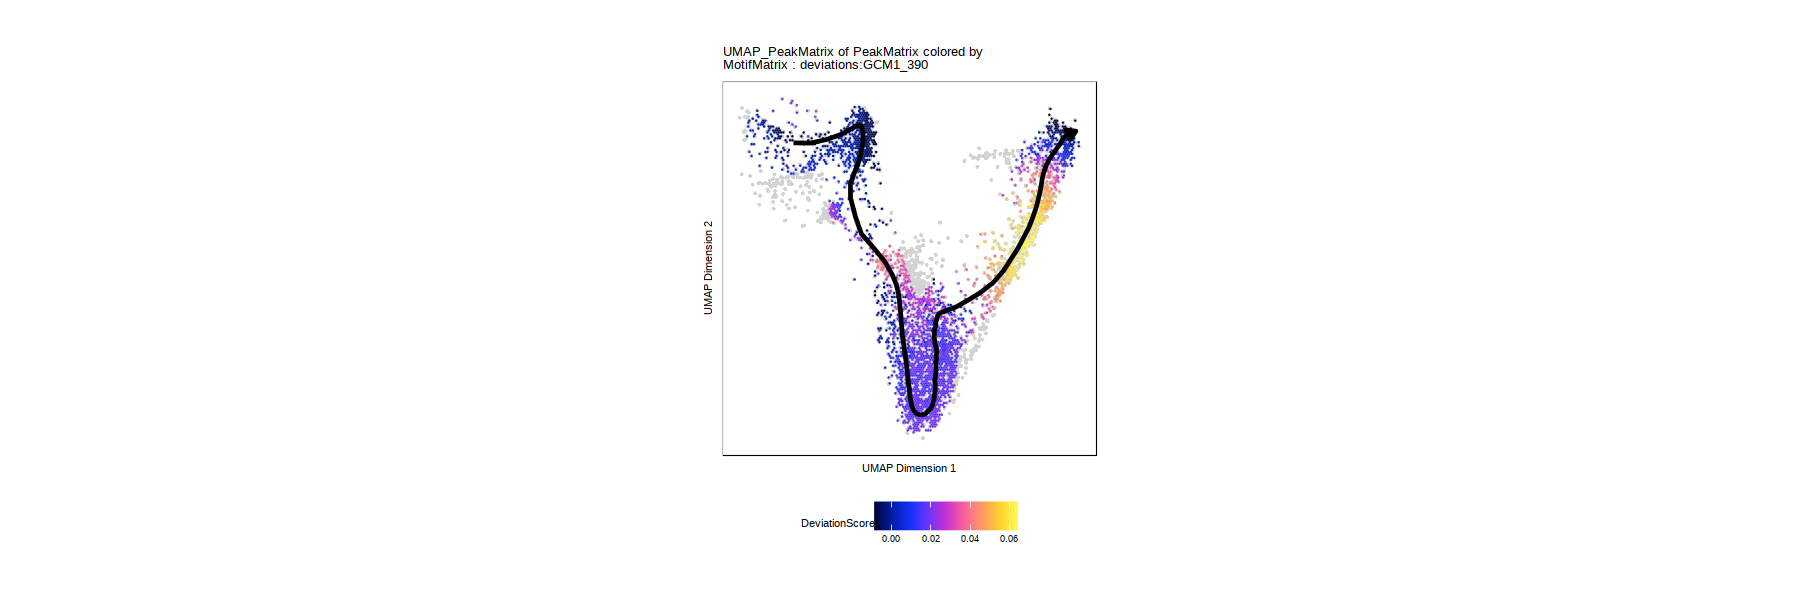

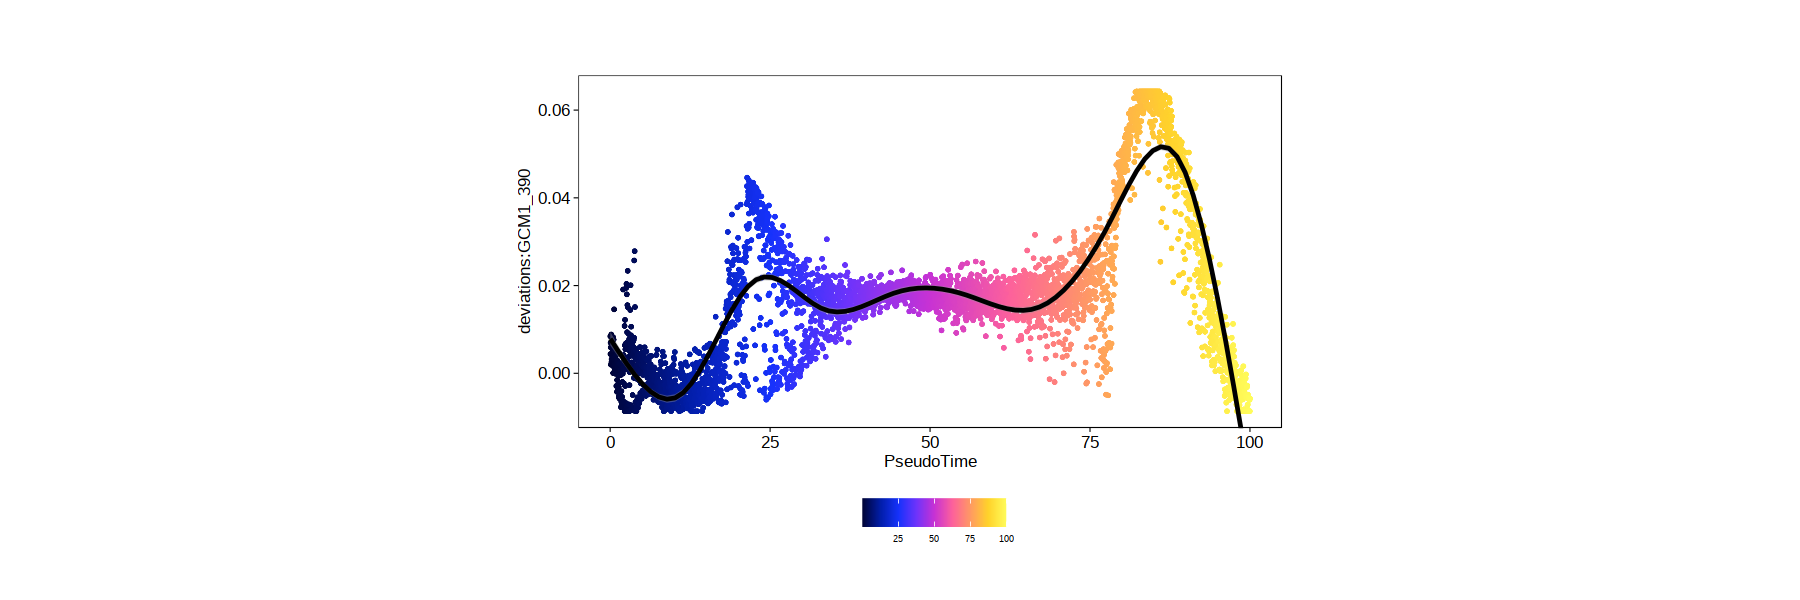

In [7]:
p = plotTrajectory(ArchRProject, 
                   trajectory = "Tropho", 
                   colorBy = "MotifMatrix", 
                   name = 'deviations:GCM1_390', 
                   continuousSet = "horizonExtra", 
                   embedding = "UMAP_PeakMatrix")
p

In [8]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "MotifMatrix", log2Norm = FALSE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

Creating Trajectory Group Matrix..

Some values are below 0, this could be a DeviationsMatrix in which scaleTo should be set = NULL.
Continuing without depth normalization!

Smoothing...



# Plotting

In [6]:
umap = getEmbedding(ArchRProject, embedding='UMAP_PeakMatrix')
colnames(umap) = c('umap1', 'umap2')
umap = as.data.frame(merge(umap, ArchRProject@cellColData, by=0))

png 
  2

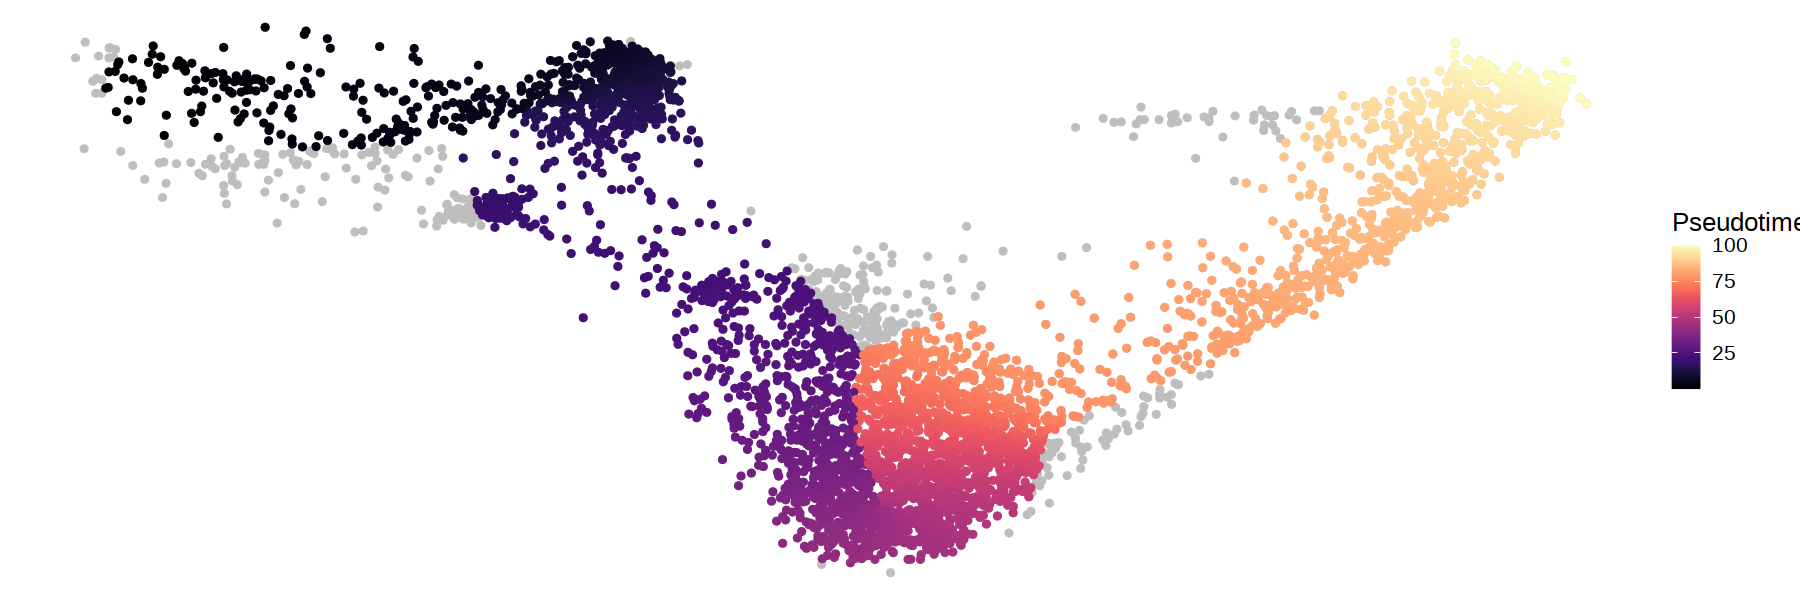

In [89]:
p = ggplot(umap, aes(umap1, umap2)) + 
    geom_point(col='grey') + 
    geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=Tropho)) + 
    scale_color_viridis(option='magma', name='Pseudotime') + 
    theme_void() + theme(text=element_text(size=15))

p
pdf(file = file.path(io$plot.trophoblast, 'Trophoblast_pseudotime.pdf'), width = 10, height = 10) 
    p 
dev.off()

In [7]:
# Get gene score matrix
GeneScore = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix")

# Rename columns & rows
gene_names = GeneScore@elementMetadata$name
GeneScore = GeneScore@assays@data$GeneScoreMatrix
rownames(GeneScore) = gene_names

# Get GeneIntegrationMatrix matrix
GeneIntegration = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "GeneIntegrationMatrix_PeakMatrix")

# Rename columns & rows
gene_names = GeneIntegration@elementMetadata$name
GeneIntegration = GeneIntegration@assays@data$GeneIntegration
rownames(GeneIntegration) = gene_names

# Get gene score matrix
Motif = getMatrixFromProject(
  ArchRProj = ArchRProject,
  useMatrix = "MotifMatrix")

# Rename columns & rows
gene_names = sapply(strsplit(Motif@elementMetadata$name,"_"), `[`, 1)
Motif = Motif@assays@data$z
rownames(Motif) = gene_names

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-1fdaf7489607c-Date-2022-01-18_Time-16-05-48.log
If there is an issue, please report to github with logFile!

2022-01-18 16:06:19 : Organizing colData, 0.514 mins elapsed.

2022-01-18 16:06:19 : Organizing rowData, 0.514 mins elapsed.

2022-01-18 16:06:19 : Organizing rowRanges, 0.515 mins elapsed.

2022-01-18 16:06:19 : Organizing Assays (1 of 1), 0.515 mins elapsed.

2022-01-18 16:06:21 : Constructing SummarizedExperiment, 0.545 mins elapsed.

2022-01-18 16:06:22 : Finished Matrix Creation, 0.558 mins elapsed.

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-1fdaf519e06af-Date-2022-01-18_Time-16-06-22.log
If there is an issue, please report to github with logFile!

2022-01-18 16:06:35 : Organizing colData, 0.23 mins elapsed.

2022-01-18 16:06:36 : Organizing rowData, 0.231 mins elapsed.

2022-01-18 16:06:36 : Organizing rowRanges, 0.231 mins elapsed.

2022-01-18 16:06:36 : Organizing Assays (1 of 1), 0.231 mins elapsed.



In [8]:
plot_traj = function(gene){
    umap = getEmbedding(ArchRProject, embedding='UMAP_PeakMatrix')
    colnames(umap) = c('umap1', 'umap2')
    umap = as.data.frame(merge(umap, ArchRProject@cellColData, by=0))
    id = gene

    
    # gene score
    imputed_genescore = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneScore[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject)))
    imputed_genescore = as.data.frame(imputed_genescore) 
    
    colnames(imputed_genescore) = 'genescore'
    
    umap = merge(umap, imputed_genescore, by.x='Row.names', by.y=0)
    
    p11 = ggplot(umap, aes(umap1, umap2)) + 
        geom_point(col='grey') + 
        geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=genescore)) + 
        scale_color_viridis(option='magma', name='GeneScore') + 
        ggtitle(gene) + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    p12 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,genescore, col= genescore)) + 
        geom_point() + 
        scale_color_viridis(option='magma', name='GeneScore') +
        geom_smooth(col='black') + 
        xlab('Pseudotime') + ylab('Gene Score') + 
        theme_classic() + 
        theme(text = element_text(size = 15), 
              legend.title=element_text(size=10))
    
    # gene integration
    imputed_geneintegration = suppressMessages(imputeMatrix(mat = t(as.matrix(GeneIntegration[id,])), 
                                     imputeWeights = getImputeWeights(ArchRProject)))
    
    imputed_geneintegration = as.data.frame(imputed_geneintegration) 
    colnames(imputed_geneintegration) = 'geneintegration'
    
    umap = merge(umap, imputed_geneintegration, by.x='Row.names', by.y=0)
    
    p21 = ggplot(umap, aes(umap1, umap2)) + 
        geom_point(col='grey') + 
        geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=geneintegration))  + 
        scale_color_viridis(option='plasma', name='GeneIntegration') + 
        ggtitle('') + 
        theme_void() + 
        theme(text=element_text(size=10), 
              plot.title = element_text(size=22))
    
    p22 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,geneintegration, col= geneintegration)) + 
        geom_point() + 
        scale_color_viridis(option='plasma', name='geneintegration') +
        geom_smooth(col='black') + 
        xlab('Pseudotime') + ylab('Gene Integration') + 
        theme_classic() + 
        theme(text = element_text(size = 15), 
              legend.title=element_text(size=10))
    
    # motifs
    if(gene %in% rownames(Motif)){
        imputed_motif = suppressMessages(imputeMatrix(mat = t(as.matrix(Motif[gene,])), 
                                         imputeWeights = getImputeWeights(ArchRProject)))

        imputed_motif = as.data.frame(imputed_motif) 
        colnames(imputed_motif) = 'motif'

        umap = merge(umap, imputed_motif, by.x='Row.names', by.y=0)

        p31 = ggplot(umap, aes(umap1, umap2)) + 
            geom_point(col='grey') + 
            geom_point(data=umap[!is.na(umap$Tropho),], aes(umap1, umap2, col=motif)) + 
            scale_color_viridis(option='viridis', name='MotifAccessibility') + 
            ggtitle('') + 
            theme_void() +
            theme(text=element_text(size=10), 
                  plot.title = element_text(size=22))

        p32 = ggplot(umap[!is.na(umap$Tropho),], aes(Tropho,motif, col= motif)) + 
            geom_point() + 
            scale_color_viridis(option='viridis', name='motif') +
            geom_smooth(col='black') + 
            xlab('Pseudotime') + ylab('Motif Accessibility') + 
            theme_classic() + 
            theme(text = element_text(size = 15), 
                  legend.title=element_text(size=10))
    
    grid.arrange(p11,p21,p31, p12, p22, p32, ncol=3)

    }else{
        grid.arrange(p11,p21,p12, p22, ncol=2)
    }

}

In [9]:
genescore_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneScoreMatrix")
genescore_genes = lapply(strsplit(genescore_genes, ":"), `[`, 2)

gene_integration_genes = getFeatures(
  ArchRProj = ArchRProject,
  useMatrix = "GeneIntegrationMatrix_PeakMatrix")
gene_integration_genes = lapply(strsplit(gene_integration_genes, ":"), `[`, 2)

all_genes = intersect(genescore_genes, gene_integration_genes)

In [10]:
genes = c(
#         'VTCN1',
#        'GCM1',
#         'PDE6H',# from https://academic.oup.com/endo/article/150/2/1000/2455727
#         'S100A4',
#         'TNNI2',
#         'COL11A1',
#         'ADAM12',
#         'FABP7',
#         'SPON2',          
#         'ND2',# Trophoblast markers atlas
#         'COX2',
#         'CDK2', 
#         'ATP6V0E1', 
#         'RPN1', 
#         'SOD1', 
#        'GATA3',
#         'HSPD1', 
#            'FABP3',
#         'NME2',
#          'ORY1',
#     'SYN1', 'SYN2',
#    'TEAD1','CDX4','CDX1', 'TEAD3', 'RREB1', 'ELF5', 'MITF', 'USF1', 'ID2', 'ID1', 'TFAP2C', 'TFAP2B', #heatmap
#     'CEPBA',
    'ENSOCUG00000029640'
         ) 

In [11]:
genes = genes[genes %in% all_genes]

In [12]:
genes

[1] "ENSOCUG00000029640"

In [13]:
for(i in genes){
    pdf(file = file.path(io$plot.trophoblast, paste0(i,'_trophoblast.pdf')), width = 15, height = 8) 
        plot_traj(i)
    dev.off()
}

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'

`geom_smooth()` using method = 'gam' and formula 'y ~ s(x, bs = "cs")'



### Motifs

In [ ]:
trajMM  <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "MotifMatrix", log2Norm = FALSE)
names = sapply(strsplit(rownames(trajMM),":"), `[`, 2)
names = sapply(strsplit(names,"_"), `[`, 1)
rownames(trajMM) = names

In [9]:
p1 = plotTrajectoryHeatmap(trajMM, pal = paletteContinuous(set = "solarExtra"), labelTop  = 100)

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c44095774e-Date-2022-01-17_Time-14-52-39.log
If there is an issue, please report to github with logFile!

useSeqnames is NULL or greater than 1 with a Sparse.Assays.Matrix trajectory input.

2022-01-17 14:52:39 : 

force=FALSE thus continuing with subsetting useSeqnames = z

2022-01-17 14:52:39 : 

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c44095774e-Date-2022-01-17_Time-14-52-39.log



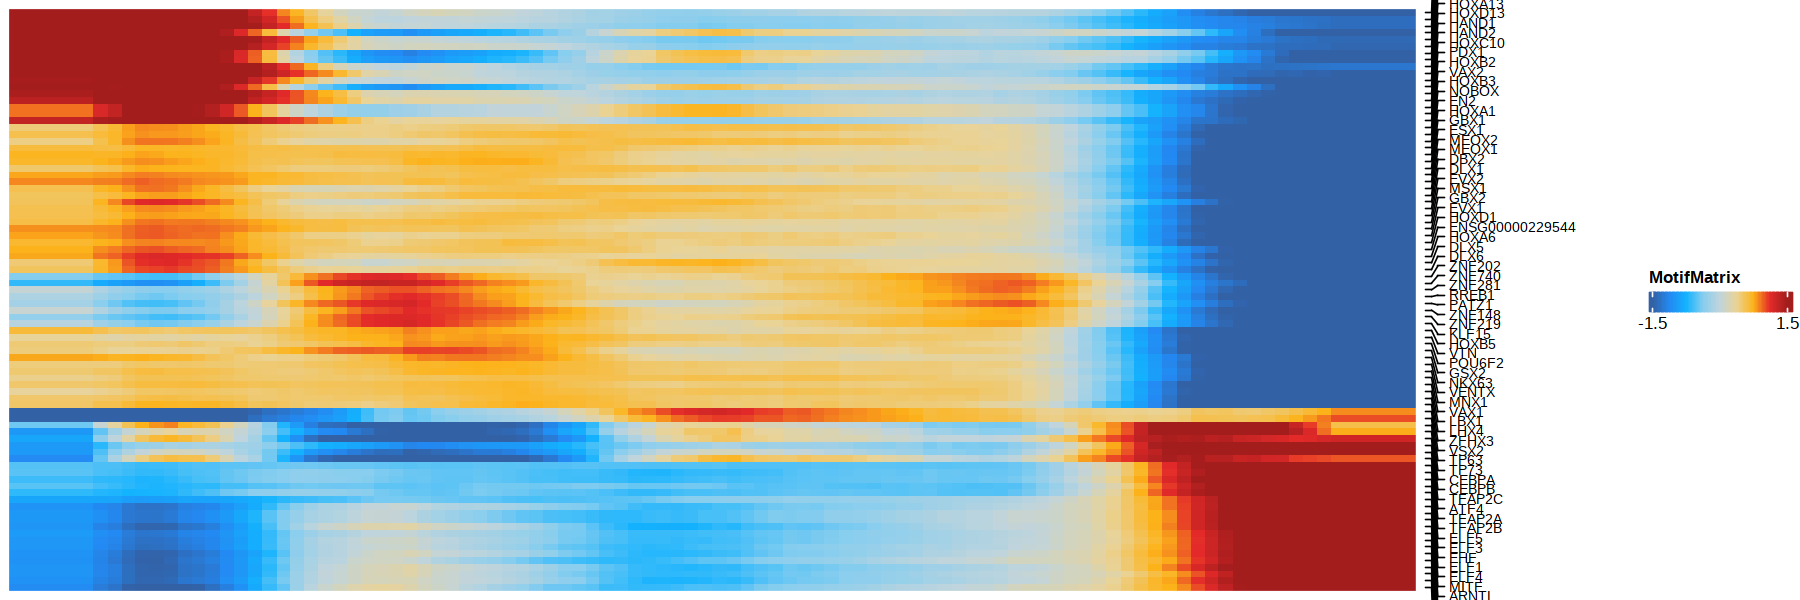

In [13]:
p1

In [10]:
# Export TF names in heatmap to select ones of interest
write.csv(rownames(p1@ht_list$MotifMatrix@matrix),file.path(io$plot.trophoblast, 'heatmap_motifs.csv'), row.names=FALSE)

In [11]:
motifs_to_keep = c('GATA3',
                   'TFAP2B',
                   'ID1',
                   'ELF3', 
                   'ETV7',
                   'RREB',
                   'VENTX',
                   'TWIST1', 
                   'TFEC'
                   
                  )
keep = grep(paste(motifs_to_keep, collapse='|'), rownames(trajMM), value = TRUE)

keep_rows = data.table('TF' = rownames(p1@ht_list$MotifMatrix@matrix), 'row' = 1:length(rownames(p1@ht_list$MotifMatrix@matrix))) %>%
    .[TF %in% keep,] %>% .$row

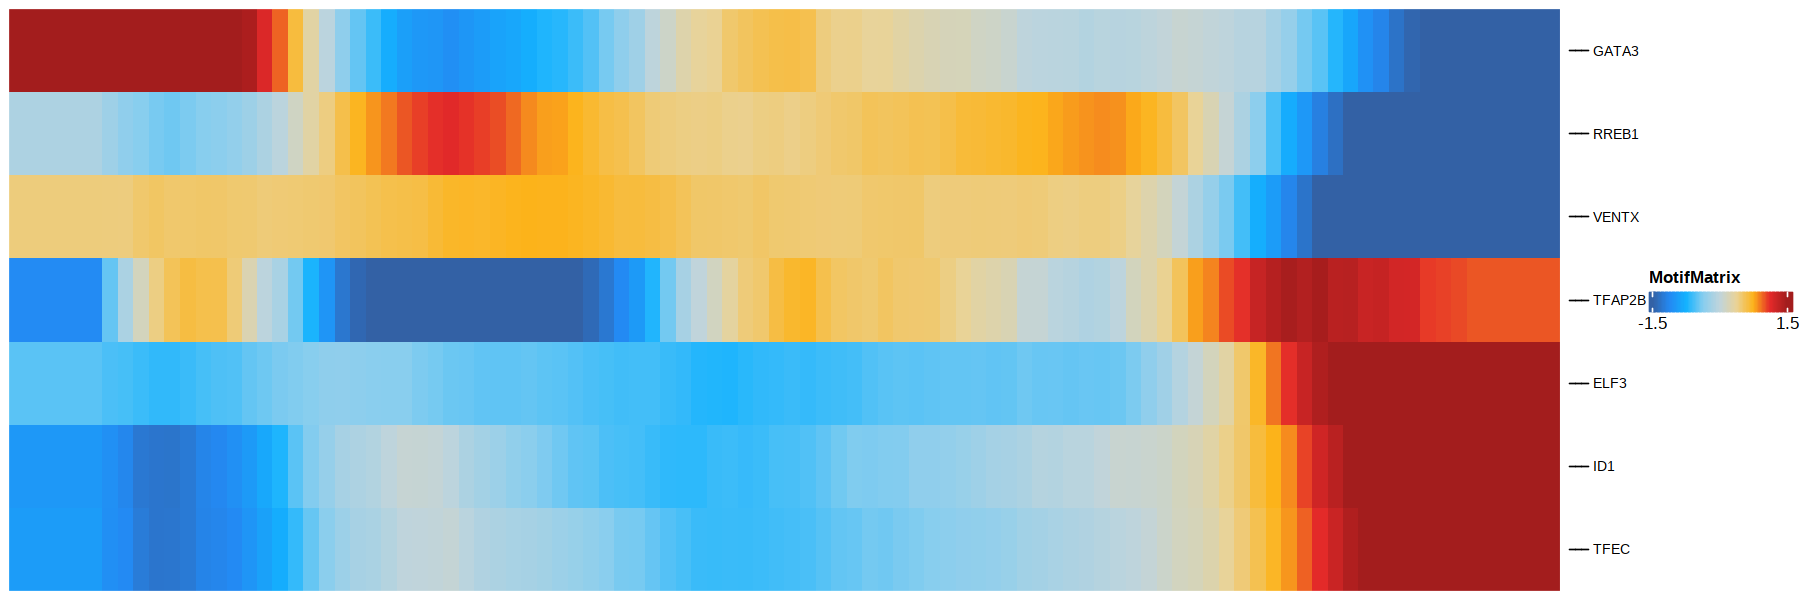

In [12]:
p1[keep_rows]

In [14]:
trajGSM <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "GeneScoreMatrix", log2Norm = TRUE)
p2 <- trajectoryHeatmap(trajGSM,  pal = paletteContinuous(set = "horizonExtra"))

Creating Trajectory Group Matrix..

Smoothing...

Warning message:
“'trajectoryHeatmap' is deprecated.
Use 'plotTrajectoryHeatmap' instead.
See help("Deprecated")”
ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c43e86393e-Date-2022-01-17_Time-14-54-09.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c43e86393e-Date-2022-01-17_Time-14-54-09.log



In [16]:
trajGIM <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "GeneIntegrationMatrix_PeakMatrix", log2Norm = FALSE)
p3 <- plotTrajectoryHeatmap(trajGIM,  pal = paletteContinuous(set = "blueYellow"))

Creating Trajectory Group Matrix..

Smoothing...

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c47458580b-Date-2022-01-17_Time-15-04-29.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c47458580b-Date-2022-01-17_Time-15-04-29.log



In [17]:
trajPM  <- getTrajectory(ArchRProj = ArchRProject, name = "Tropho", useMatrix = "PeakMatrix", log2Norm = TRUE)
p4 <- plotTrajectoryHeatmap(trajPM, pal = paletteContinuous(set = "solarExtra"))

Creating Trajectory Group Matrix..

Smoothing...

ArchR logging to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c47b03dec3-Date-2022-01-17_Time-15-05-11.log
If there is an issue, please report to github with logFile!

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotTrajectoryHeatmap-b5c47b03dec3-Date-2022-01-17_Time-15-05-11.log



In [19]:
plotPDF(p1, p2, p3, p4, name = "Plot-Tropho-Traj-Heatmaps.pdf", ArchRProj = ArchRProject, addDOC = FALSE, width = 6, height = 8)

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!

Plotting ComplexHeatmap!



In [70]:
args = list()
args$nfeatures <- 15000
args$matrix <- 'PeakMatrix'
args$ndims <- 15
args$n_neighbors <- 35
args$min_dist <- 0.3
args$seed <- 42

# Options
opts$lsi.iterations = 2
opts$lsi.cluster.resolution = 0.5

In [71]:
dim_redu = function(){

###########################
## Latent Semantic Index ##
###########################

# Iterative LSI: two iterations
ArchRProject <- addIterativeLSI(
  ArchRProj = ArchRProject,
  useMatrix = args$matrix, 
  name = args$matrix, 
  dimsToUse = 1:args$ndims,
  firstSelection = "Top",
  depthCol = "nFrags",
  iterations = opts$lsi.iterations, 
  saveIterations = FALSE,
  varFeatures = args$nfeatures, 
  force = TRUE
)

# Add clusters
ArchRProject <- addClusters(input = ArchRProject,  
                         reducedDims = args$matrix,
                         resolution = opts$lsi.cluster.resolution, 
                         force=TRUE)

ArchRProject <- addUMAP(
  ArchRProj = ArchRProject, 
  reducedDims = args$matrix,
  name = paste0("UMAP_", args$matrix),
  metric = "cosine",
  nNeighbors = args$n_neighbors, 
  minDist = args$min_dist, 
  seed = args$seed,
  saveModel = FALSE,
  force = TRUE)
    
    return(ArchRProject)
}

Checking Inputs...

ArchR logging to : ArchRLogs/ArchR-addIterativeLSI-340ff700f6dc3-Date-2022-01-14_Time-14-42-25.log
If there is an issue, please report to github with logFile!

2022-01-14 14:42:26 : Computing Total Across All Features, 0.004 mins elapsed.

2022-01-14 14:42:27 : Computing Top Features, 0.016 mins elapsed.

###########
2022-01-14 14:42:28 : Running LSI (1 of 2) on Top Features, 0.037 mins elapsed.
###########

2022-01-14 14:42:28 : Creating Partial Matrix, 0.037 mins elapsed.

2022-01-14 14:42:36 : Computing LSI, 0.178 mins elapsed.

2022-01-14 14:42:45 : Identifying Clusters, 0.322 mins elapsed.

2022-01-14 14:42:50 : Identified 6 Clusters, 0.402 mins elapsed.

2022-01-14 14:42:50 : Creating Cluster Matrix on the total Group Features, 0.402 mins elapsed.

2022-01-14 14:43:17 : Computing Variable Features, 0.849 mins elapsed.

###########
2022-01-14 14:43:17 : Running LSI (2 of 2) on Variable Features, 0.85 mins elapsed.
###########

2022-01-14 14:43:17 : Creating Par

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4495
Number of edges: 159312

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8577
Number of communities: 9
Elapsed time: 0 seconds


2022-01-14 14:43:38 : Testing Outlier Clusters, 0.073 mins elapsed.

2022-01-14 14:43:38 : Assigning Cluster Names to 9 Clusters, 0.073 mins elapsed.

2022-01-14 14:43:38 : Finished addClusters, 0.074 mins elapsed.

14:43:38 UMAP embedding parameters a = 0.9922 b = 1.112

14:43:38 Read 4495 rows and found 15 numeric columns

14:43:38 Using Annoy for neighbor search, n_neighbors = 35

14:43:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

14:43:39 Writing NN index file to temp file /tmp/RtmpMofMdp/file340ff202e75fa

14:43:39 Searching Annoy index using 16 threads, search_k = 3500

14:43:39 Annoy recall = 100%

14:43:40 Commencing smooth kNN distance calibration using 16 threads

14:43:42 Initializing from normalized Laplacian + noise

14:43:42 Commencing optimization 

In [61]:
plot_dim_redu = function(){
p1 = plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "cellColData", 
            name = "stage")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))

p2 = plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "cellColData", 
            name = "Clusters_PeakMatrix")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))

p3 = plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "cellColData", 
            name = "celltype_manual_refined")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))

ggarrange(p1, p2, p3)
}

In [62]:
suppressMessages(dim_redu())

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4495
Number of edges: 206909

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8602
Number of communities: 7
Elapsed time: 0 seconds



           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Trophoblast 
samples(3): rabbit_BGRGP1 rabbit_BGRGP3 rabbit_BGRGP2
sampleColData names(1): ArrowFiles
cellColData names(43): stage_clusters.3 sample ...
  celltype_manual_refined Clusters
numberOfCells(1): 4495
medianTSS(1): 3.093
medianFrags(1): 39653

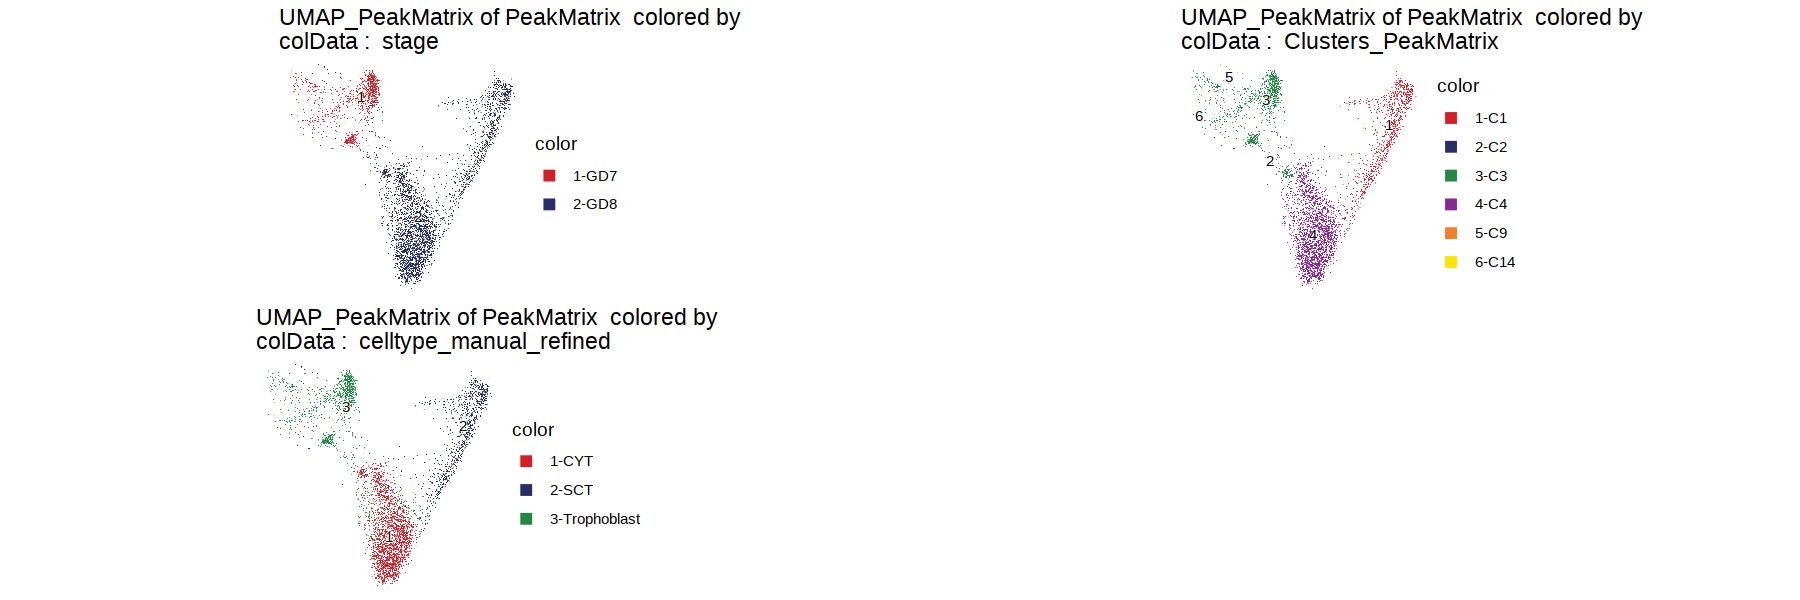

In [63]:
suppressMessages(plot_dim_redu()) 

In [105]:
args$matrix = 'PeakMatrix'
args$ndims <- 25
args$n_neighbors <- 35
args$min_dist <- 0.5
opts$lsi.cluster.resolution = 0.2

ArchRProject = suppressMessages(dim_redu())

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4903
Number of edges: 211190

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9297
Number of communities: 5
Elapsed time: 0 seconds


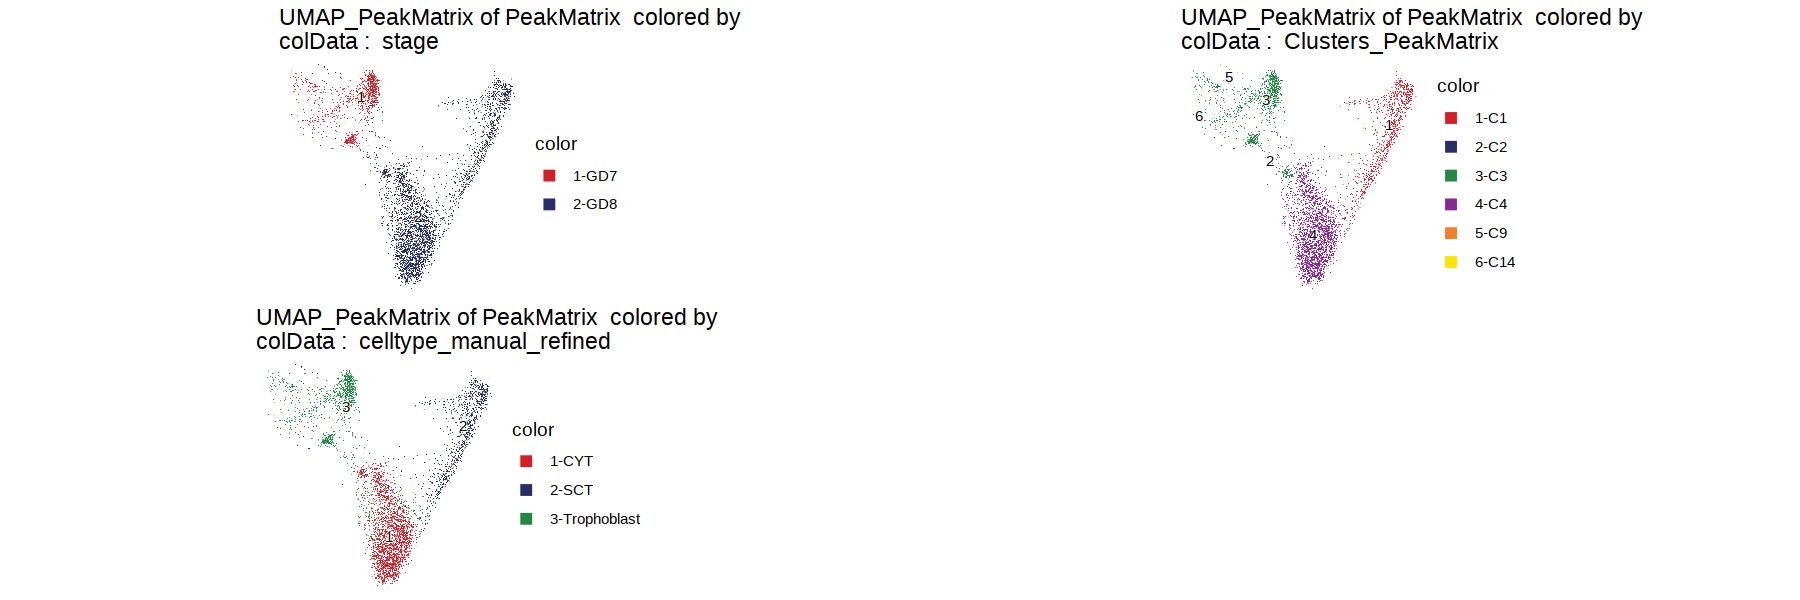

In [58]:
suppressMessages(plot_dim_redu()) 

# Rerun RNA integration with only relevant celltypes

In [23]:
args$matrix = 'PeakMatrix'
addArchRThreads(1)

Setting default number of Parallel threads to 1.



In [24]:
# Load RNA & select only relevant celltypes
io$RNA_in <- file.path(io$basedir,"RNA/RangedSummarizedExperiment.rds")
sceRNA = readRDS(io$RNA_in)

In [25]:
unique(sceRNA@colData$celltype)

[1] "Epiblast"                       "Visceral YS Endoderm"          
 [3] "Trophoblast"                    "Primitive Streak"              
 [5] "Hypoblast"                      "CYT"                           
 [7] "Haematoendothelial progenitors" "Anterior Hypoblast"            
 [9] "Notochord"                      "Placodes"                      
[11] "Neural Crest"                   "Parietal YS Endoderm"          
[13] "Early Amniotic Ectoderm"        "Posterior Mesoderm"            
[15] "Brain/Neural Tube"              "Late Amniotic Ectoderm"        
[17] "Somitic Mesoderm"               "Cranial Mesoderm"              
[19] "NMP"                            "Endothelium"                   
[21] "Limb Ectoderm"                  "Early Erythrocytes"            
[23] "Anterior Mesoderm"              "EXE mesoderm"                  
[25] "SCT"                            "Gut"                           
[27] "YS Mesothelium"                 "Cardiomyocytes"                
[29] "Late Erythrocytes"              "Chorion"                       
[31] "Allantois"                      "Megakaryocytes"                
[33] "Floor Plate"

In [26]:
keep = c('Trophoblast', 'CYT', 'SCT', 'Late Amniotic Ectoderm', 'Early Amniotic Ectoderm', 'Visceral YS Endoderm')
keep = c('Trophoblast', 'CYT', 'SCT')
sceRNA = sceRNA[,sceRNA@colData$celltype %in% keep]

In [27]:
# Add imputation 
ArchRProject <- addImputeWeights(ArchRProject, 
                                reducedDims = args$matrix)

# Integrate
ArchRProject <- addGeneIntegrationMatrix(
    ArchRProj = ArchRProject, 
    useMatrix = "GeneScoreMatrix",
    matrixName = paste0("GeneIntegrationMatrix_", args$matrix),
    reducedDims =  args$matrix,
    seRNA = sceRNA,
    addToArrow = TRUE,
    force= TRUE,
    groupRNA = "celltype",
    nameCell = "predictedCell_Un",
    nameGroup = paste0("Tropho_traj_celltype_", args$matrix),
    nameScore = "predictedScore_celltype")

ArchR logging to : ArchRLogs/ArchR-addImputeWeights-340ff3a86c24c-Date-2022-01-14_Time-11-25-20.log
If there is an issue, please report to github with logFile!

2022-01-14 11:25:20 : Computing Impute Weights Using Magic (Cell 2018), 0 mins elapsed.

Warning message in sprintf("Completed Getting Magic Weights!", round(object.size(weightList)/10^9, :
“one argument not used by format 'Completed Getting Magic Weights!'”
ArchR logging to : ArchRLogs/ArchR-addGeneIntegrationMatrix-340ff7a67dad1-Date-2022-01-14_Time-11-25-30.log
If there is an issue, please report to github with logFile!

2022-01-14 11:25:30 : Running Seurat's Integration Stuart* et al 2019, 0.002 mins elapsed.

Warning message:
“package ‘Seurat’ was built under R version 4.1.2”
2022-01-14 11:25:40 : Checking ATAC Input, 0.16 mins elapsed.

2022-01-14 11:25:40 : Checking RNA Input, 0.16 mins elapsed.

Warning message:
“Non-unique features (rownames) present in the input matrix, making unique”
Warning message:
“Feature names c

In [30]:
suppressMessages(dim_redu())

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5599
Number of edges: 257564

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8872
Number of communities: 11
Elapsed time: 0 seconds



           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC_final/ArchR/Trophoblast 
samples(4): rabbit_BGRGP1 rabbit_BGRGP3 rabbit_BGRGP2 rabbit_BGRGP4
sampleColData names(1): ArrowFiles
cellColData names(44): stage_clusters.3 sample ...
  Tropho_traj_celltype_PeakMatrix Clusters
numberOfCells(1): 5599
medianTSS(1): 3.038
medianFrags(1): 40094

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-340ff408f9b18-Date-2022-01-14_Time-11-34-19.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-340ff408f9b18-Date-2022-01-14_Time-11-34-19.log

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-340ff2b02c066-Date-2022-01-14_Time-11-34-20.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = cellColData

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-340ff2b02c066-Date-2022-01-14_Time-11-34-20.log



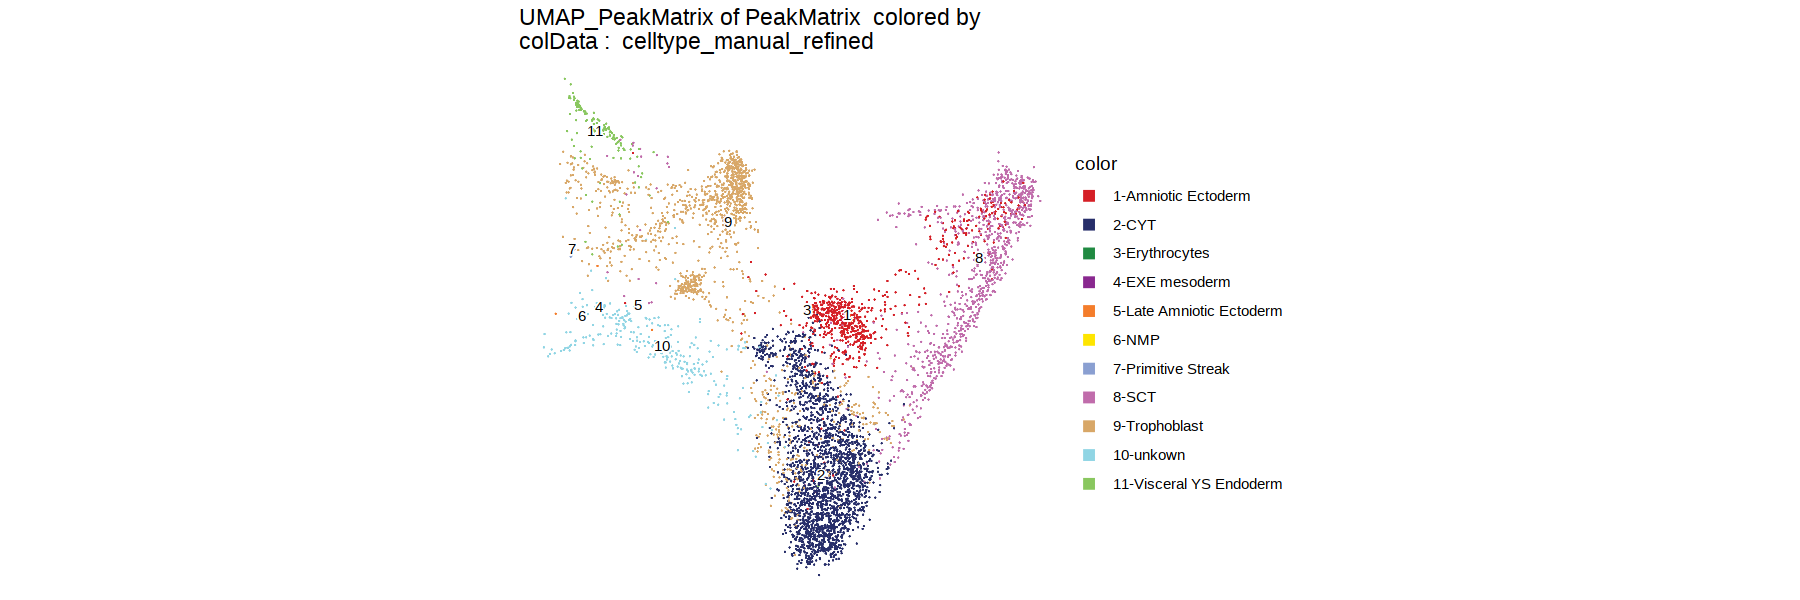

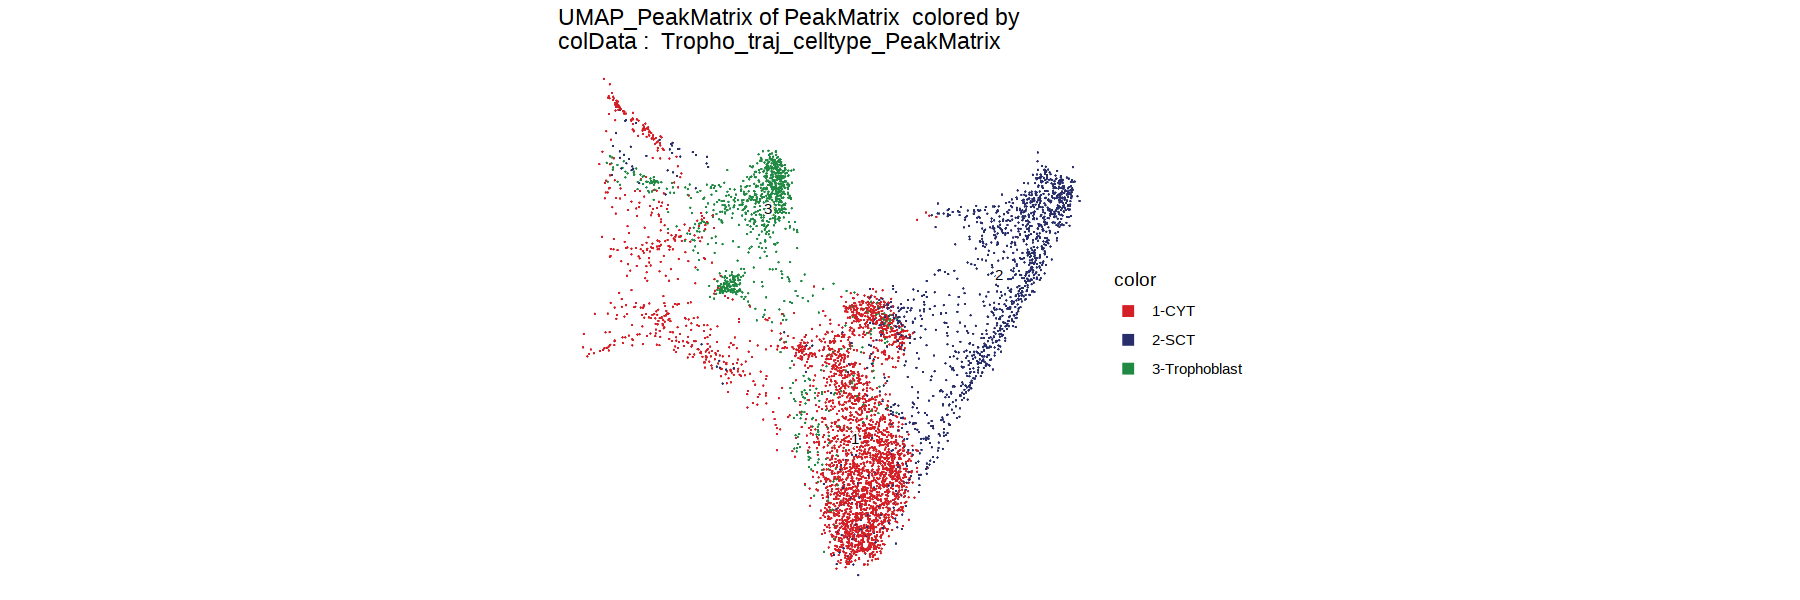

In [31]:
plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "cellColData", 
            name = "celltype_manual_refined")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))
plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "cellColData", 
            name = "Tropho_traj_celltype_PeakMatrix")+ theme_void() + theme(plot.margin=grid::unit(c(0,0,0,0), "mm"))

In [11]:
getAvailableMatrices(ArchRProject)

[1] "GeneIntegrationMatrix_PeakMatrix" "GeneIntegrationMatrix_TileMatrix"
[3] "GeneScoreMatrix"                  "MotifMatrix"                     
[5] "PeakMatrix"                       "TileMatrix"

In [14]:
colnames(ArchRProject@cellColData)

[1] "stage_clusters.3"                    
 [2] "sample"                              
 [3] "Sample"                              
 [4] "TSSEnrichment"                       
 [5] "ReadsInTSS"                          
 [6] "ReadsInPromoter"                     
 [7] "PromoterRatio"                       
 [8] "PassQC"                              
 [9] "NucleosomeRatio"                     
[10] "nMultiFrags"                         
[11] "nMonoFrags"                          
[12] "nFrags"                              
[13] "nDiFrags"                            
[14] "DoubletScore"                        
[15] "DoubletEnrichment"                   
[16] "stage"                               
[17] "cell"                                
[18] "stage_mapping"                       
[19] "predictedCell_Un"                    
[20] "predictedGroup_celltype_TileMatrix"  
[21] "predictedScore_celltype"             
[22] "stage_clusters"                      
[23] "cell.1"                              
[24] "Clusters_TileMatrix"                 
[25] "ReadsInPeaks"                        
[26] "FRIP"                                
[27] "predictedCell_Un.1"                  
[28] "predictedGroup_celltype_PeakMatrix"  
[29] "predictedScore_celltype.1"           
[30] "stage_clusters.1"                    
[31] "cell.2"                              
[32] "Clusters_PeakMatrix"                 
[33] "predictedCell_Un.2"                  
[34] "predictedGroup_celltype_TileMatrix.1"
[35] "predictedScore_celltype.2"           
[36] "stage_clusters.2"                    
[37] "cell.3"                              
[38] "predictedCell_Un.3"                  
[39] "predictedGroup_celltype_PeakMatrix.1"
[40] "predictedScore_celltype.3"           
[41] "cell.4"                              
[42] "celltype_manual_refined"

Getting ImputeWeights

ArchR logging to : ArchRLogs/ArchR-plotEmbedding-340ff770042df-Date-2022-01-14_Time-11-34-22.log
If there is an issue, please report to github with logFile!

Getting UMAP Embedding

ColorBy = GeneScoreMatrix

Getting Matrix Values...

2022-01-14 11:34:23 : 

1 
2 
3 
4 


Imputing Matrix

Using weights on disk

1 of 1

Using weights on disk

1 of 1

Plotting Embedding

1 


ArchR logging successful to : ArchRLogs/ArchR-plotEmbedding-340ff770042df-Date-2022-01-14_Time-11-34-22.log



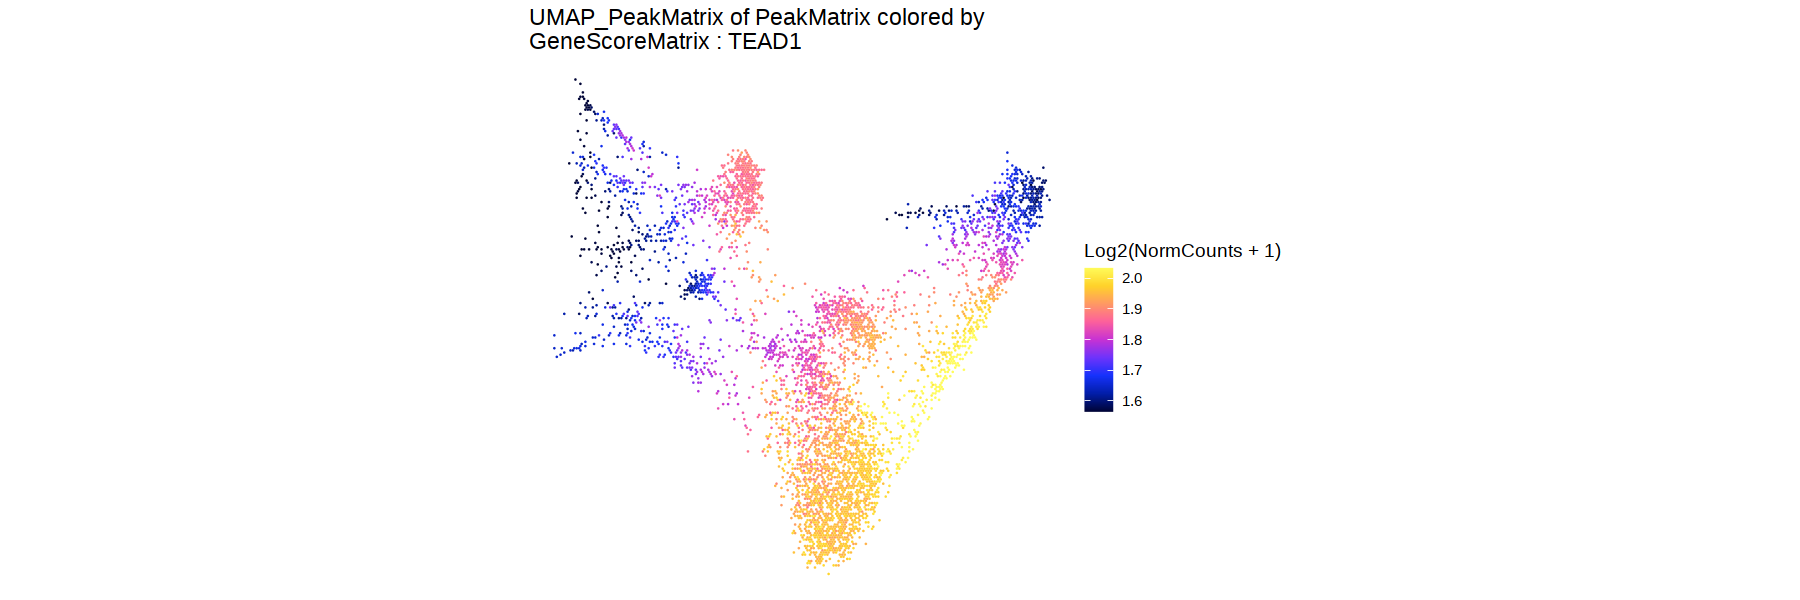

In [32]:
plotEmbedding(ArchRProject, 
              embedding=paste0('UMAP_', args$matrix),
              colorBy = "GeneScoreMatrix", 
            name = "TEAD1")+ theme_void()